In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../../data/raw/dataset.csv")

df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


In [3]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

df.info()

Shape: (100000, 28)

Columns:
 ['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age      

In [4]:
df["Customer_ID"].nunique()

12500

In [5]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


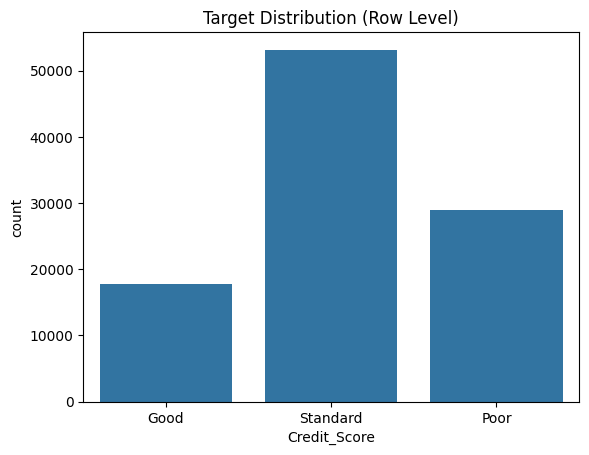

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Credit_Score", data=df)
plt.title("Target Distribution (Row Level)")
plt.show()

In [8]:
for col in df.columns:
    if df[col].dtype == "object":
        print(f"\n{col}")
        print(df[col].unique()[:10])
        print("Total Unique:", df[col].nunique())


Name
['Aaron Maashoh' 'Rick Rothackerj' 'Langep' 'Jasond' 'Deepaa' 'Np'
 'Nadiaq' 'Annk' 'Charlie Zhur' 'Jamesj']
Total Unique: 10128

Occupation
['Scientist' 'Teacher' 'Engineer' 'Entrepreneur' 'Developer' 'Lawyer'
 'Media_Manager' 'Doctor' 'Journalist' 'Manager']
Total Unique: 15

Type_of_Loan
['Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan'
 'Credit-Builder Loan' 'Auto Loan, Auto Loan, and Not Specified'
 'Not Specified' 'No Data' 'Credit-Builder Loan, and Mortgage Loan'
 'Not Specified, Auto Loan, and Student Loan'
 'Personal Loan, Debt Consolidation Loan, and Auto Loan'
 'Not Specified, and Payday Loan'
 'Credit-Builder Loan, Personal Loan, and Auto Loan']
Total Unique: 6261

Credit_Mix
['Good' 'Standard' 'Bad']
Total Unique: 3

Payment_of_Min_Amount
['No' 'NM' 'Yes']
Total Unique: 3

Payment_Behaviour
['High_spent_Small_value_payments' 'Low_spent_Large_value_payments'
 'Low_spent_Medium_value_payments' 'Low_spent_Small_value_payments'
 'High_spent_Medium_va

In [9]:
cols_to_drop = ["ID", "Name", "SSN", "Type_of_Loan"]

df = df.drop(columns=cols_to_drop, errors="ignore")

df.head()

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,3392,1,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,3392,2,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,3392,3,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,3392,4,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,3392,5,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


In [10]:
print("Payment_of_Min_Amount:", df["Payment_of_Min_Amount"].unique())
print("\nPayment_Behaviour:", df["Payment_Behaviour"].unique()[:10])
print("\nOccupation:", df["Occupation"].unique())

Payment_of_Min_Amount: ['No' 'NM' 'Yes']

Payment_Behaviour: ['High_spent_Small_value_payments' 'Low_spent_Large_value_payments'
 'Low_spent_Medium_value_payments' 'Low_spent_Small_value_payments'
 'High_spent_Medium_value_payments' 'High_spent_Large_value_payments']

Occupation: ['Scientist' 'Teacher' 'Engineer' 'Entrepreneur' 'Developer' 'Lawyer'
 'Media_Manager' 'Doctor' 'Journalist' 'Manager' 'Accountant' 'Musician'
 'Mechanic' 'Writer' 'Architect']


In [11]:
df["Payment_of_Min_Amount"] = df["Payment_of_Min_Amount"].replace("NM", "No")

df["Payment_of_Min_Amount"].unique()

array(['No', 'Yes'], dtype=object)

In [12]:
numeric_cols = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Num_of_Loan",
    "Interest_Rate",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "Total_EMI_per_month",
    "Monthly_Balance"
]

for col in numeric_cols:
    print(f"\n{col}")
    print("Min:", df[col].min())
    print("Max:", df[col].max())


Age
Min: 14.0
Max: 56.0

Annual_Income
Min: 7005.93
Max: 179987.28

Monthly_Inhand_Salary
Min: 303.6454166666666
Max: 15204.633333333331

Num_Bank_Accounts
Min: 0.0
Max: 11.0

Num_Credit_Card
Min: 0.0
Max: 11.0

Num_of_Loan
Min: 0.0
Max: 9.0

Interest_Rate
Min: 1.0
Max: 34.0

Delay_from_due_date
Min: 0.0
Max: 62.0

Num_of_Delayed_Payment
Min: 0.0
Max: 25.0

Outstanding_Debt
Min: 0.23
Max: 4998.07

Credit_Utilization_Ratio
Min: 20.0
Max: 50.00000000000001

Total_EMI_per_month
Min: 0.0
Max: 1779.1032538262775

Monthly_Balance
Min: 0.0077596647753352
Max: 1183.9306960885192


In [13]:
df = df[df["Age"] >= 18]
df = df[df["Annual_Income"] > 0]
df = df[df["Monthly_Inhand_Salary"] > 0]

print("New Shape:", df.shape)

New Shape: (94132, 24)


In [14]:
# Debt to Income Ratio
df["DTI_Ratio"] = df["Total_EMI_per_month"] / df["Monthly_Inhand_Salary"]

# Income Utilization (how much is being used)
df["Income_Utilization"] = df["Total_EMI_per_month"] / df["Monthly_Inhand_Salary"]

# Debt Burden
df["Debt_to_Income"] = df["Outstanding_Debt"] / df["Annual_Income"]

df.head()

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,DTI_Ratio,Income_Utilization,Debt_to_Income
0,3392,1,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good,0.027167,0.027167,0.042376
1,3392,2,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good,0.027167,0.027167,0.042376
2,3392,3,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good,0.027167,0.027167,0.042376
3,3392,4,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good,0.027167,0.027167,0.042376
4,3392,5,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good,0.027167,0.027167,0.042376


In [15]:
# Keep DTI
df["DTI_Ratio"] = df["Total_EMI_per_month"] / df["Monthly_Inhand_Salary"]

# Redefine Income Utilization properly
df["Income_Utilization"] = df["Amount_invested_monthly"] / df["Monthly_Inhand_Salary"]

# Debt to Income stays same
df["Debt_to_Income"] = df["Outstanding_Debt"] / df["Annual_Income"]

df.head()


,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,DTI_Ratio,Income_Utilization,Debt_to_Income
0,3392,1,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good,0.027167,0.011763,0.042376
1,3392,2,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good,0.027167,0.011763,0.042376
2,3392,3,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good,0.027167,0.011763,0.042376
3,3392,4,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good,0.027167,0.011763,0.042376
4,3392,5,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good,0.027167,0.011763,0.042376


In [21]:
customer_df = df.groupby("Customer_ID").agg({

    # Numeric features
    "Age": "mean",
    "Annual_Income": "mean",
    "Monthly_Inhand_Salary": "mean",

    "Num_Bank_Accounts": "mean",
    "Num_Credit_Card": "mean",
    "Num_of_Loan": "mean",

    "Interest_Rate": "mean",
    "Delay_from_due_date": "mean",
    "Num_of_Delayed_Payment": "mean",

    "Outstanding_Debt": "mean",
    "Credit_Utilization_Ratio": "mean",

    "Total_EMI_per_month": "mean",
    "Monthly_Balance": "mean",

    "Credit_History_Age": "max",

    # Engineered features
    "DTI_Ratio": "mean",
    "Income_Utilization": "mean",
    "Debt_to_Income": "mean",

    # Categorical features (MOST IMPORTANT FIX)
    "Occupation": lambda x: x.mode()[0],
    "Credit_Mix": lambda x: x.mode()[0],
    "Payment_of_Min_Amount": lambda x: x.mode()[0],
    "Payment_Behaviour": lambda x: x.mode()[0],

    # Target
    "Credit_Score": lambda x: x.mode()[0]

}).reset_index()

customer_df.head()

,Customer_ID,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Num_of_Loan,Interest_Rate,Delay_from_due_date,Num_of_Delayed_Payment,...,Monthly_Balance,Credit_History_Age,DTI_Ratio,Income_Utilization,Debt_to_Income,Occupation,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour,Credit_Score
0,1006,37.875,16756.18,1331.348333,9.0,6.0,2.0,22.0,48.000,11.750,...,314.626667,189.0,0.020612,0.034026,0.115881,Journalist,Standard,Yes,Low_spent_Small_value_payments,Poor
1,1007,48.000,21212.91,1496.742500,3.0,4.0,3.0,10.0,18.625,19.375,...,285.607087,353.0,0.030564,0.020293,0.046818,Manager,Standard,No,Low_spent_Small_value_payments,Standard
2,1008,37.000,33540.43,2655.035833,6.0,3.0,0.0,17.0,25.625,11.250,...,362.407369,299.0,0.000000,0.019182,0.033958,Developer,Standard,Yes,High_spent_Small_value_payments,Standard
3,1009,22.125,80983.64,6692.636667,6.0,3.0,4.0,15.0,19.000,18.250,...,523.000149,338.0,0.028159,0.015109,0.012131,Accountant,Standard,Yes,High_spent_Medium_value_payments,Standard
4,1011,43.875,104142.56,8433.546667,3.0,5.0,3.0,5.0,18.750,14.625,...,445.787831,186.0,0.030561,0.012152,0.013172,Writer,Standard,Yes,Low_spent_Medium_value_payments,Standard


In [22]:
print(customer_df.shape)

(11812, 23)


In [23]:
customer_df.columns

Index(['Customer_ID', 'Age', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Num_of_Loan', 'Interest_Rate',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Monthly_Balance',
       'Credit_History_Age', 'DTI_Ratio', 'Income_Utilization',
       'Debt_to_Income', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour', 'Credit_Score'],
      dtype='object')

In [24]:
customer_df.select_dtypes(include=["object"]).columns

Index(['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour', 'Credit_Score'],
      dtype='object')

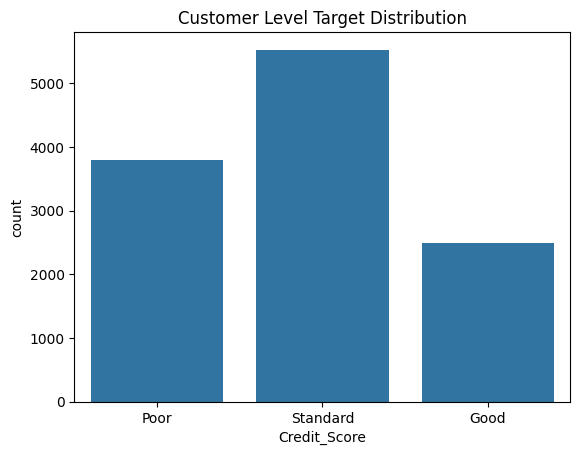

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Credit_Score", data=customer_df)
plt.title("Customer Level Target Distribution")
plt.show()

In [34]:
X = customer_df.drop(columns=["Customer_ID", "Credit_Score"])
y = customer_df["Credit_Score"]

X = pd.get_dummies(X, drop_first=True)

In [35]:
X.select_dtypes(include=["object"]).columns

Index([], dtype='object')

In [36]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
X.head()

(11812, 39)


,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Num_of_Loan,Interest_Rate,Delay_from_due_date,Num_of_Delayed_Payment,Outstanding_Debt,...,Occupation_Teacher,Occupation_Writer,Credit_Mix_Good,Credit_Mix_Standard,Payment_of_Min_Amount_Yes,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
0,37.875,16756.18,1331.348333,9.0,6.0,2.0,22.0,48.000,11.750,1941.73,...,False,False,False,True,True,False,False,False,False,True
1,48.000,21212.91,1496.742500,3.0,4.0,3.0,10.0,18.625,19.375,993.15,...,False,False,False,True,False,False,False,False,False,True
2,37.000,33540.43,2655.035833,6.0,3.0,0.0,17.0,25.625,11.250,1138.97,...,False,False,False,True,True,False,True,False,False,False
3,22.125,80983.64,6692.636667,6.0,3.0,4.0,15.0,19.000,18.250,982.44,...,False,False,False,True,True,True,False,False,False,False
4,43.875,104142.56,8433.546667,3.0,5.0,3.0,5.0,18.750,14.625,1371.80,...,False,True,False,True,True,False,False,False,True,False


In [37]:
X = X.astype(int)
X.head()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Num_of_Loan,Interest_Rate,Delay_from_due_date,Num_of_Delayed_Payment,Outstanding_Debt,...,Occupation_Teacher,Occupation_Writer,Credit_Mix_Good,Credit_Mix_Standard,Payment_of_Min_Amount_Yes,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
0,37,16756,1331,9,6,2,22,48,11,1941,...,0,0,0,1,1,0,0,0,0,1
1,48,21212,1496,3,4,3,10,18,19,993,...,0,0,0,1,0,0,0,0,0,1
2,37,33540,2655,6,3,0,17,25,11,1138,...,0,0,0,1,1,0,1,0,0,0
3,22,80983,6692,6,3,4,15,19,18,982,...,0,0,0,1,1,1,0,0,0,0
4,43,104142,8433,3,5,3,5,18,14,1371,...,0,1,0,1,1,0,0,0,1,0


In [41]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Logistic Regression (scaled)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Logistic Regression:", accuracy_score(y_test, lr_pred))
print("Decision Tree:", accuracy_score(y_test, dt_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))

Logistic Regression: 0.6923402454506983
Decision Tree: 0.6411341515023276
Random Forest: 0.751163774862463
